In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

In [6]:
from google.colab import drive
drive.mount("/content/gdrive")

Mounted at /content/gdrive


In [10]:
BASE_DIR = Path("/content/gdrive/MyDrive/rostat")

PRICE_DIR = BASE_DIR / "processed"
SALES_DIR = BASE_DIR / "processed_sales"
MONTHLY_DIR = BASE_DIR / "monthly_forecast"

RESULT_DIR = BASE_DIR / "final_q4_2025_forecast"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

In [11]:
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mask = y_true != 0

    return np.mean(
        np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])
    ) * 100


def smape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denominator != 0

    return np.mean(
        np.abs(y_true[mask] - y_pred[mask]) / denominator[mask]
    ) * 100


def calculate_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": mape(y_true, y_pred),
        "sMAPE": smape(y_true, y_pred)
    }

In [12]:
monthly_data = pd.read_csv(
    MONTHLY_DIR / "monthly_price_index_dataset.csv",
    parse_dates=["month_end"]
)

monthly_data = monthly_data.sort_values(
    ["product_group_code", "month_end"]
).reset_index(drop=True)

monthly_data["year"] = monthly_data["month_end"].dt.year
monthly_data["month"] = monthly_data["month_end"].dt.month

monthly_data = monthly_data[monthly_data["year"] <= 2025].copy()

print("Период месячных данных:", monthly_data["month_end"].min(), "—", monthly_data["month_end"].max())
print("Категорий:", monthly_data["product_group_code"].nunique())

Период месячных данных: 2016-01-31 00:00:00 — 2025-12-31 00:00:00
Категорий: 9


In [13]:
price_target_col = "price_index"

price_q4_start = pd.Timestamp("2025-10-31")
price_q4_end = pd.Timestamp("2025-12-31")

price_train_end = pd.Timestamp("2025-09-30")

In [14]:
price_sarima_configs = [
    {
        "model": "SARIMA (0,1,0)(0,1,0,12)",
        "model_type": "SARIMA",
        "component_test": "только дифференцирование и сезонность",
        "order": (0, 1, 0),
        "seasonal_order": (0, 1, 0, 12)
    },
    {
        "model": "SARIMA (0,1,1)(0,1,0,12)",
        "model_type": "SARIMA",
        "component_test": "добавлена MA-компонента",
        "order": (0, 1, 1),
        "seasonal_order": (0, 1, 0, 12)
    },
    {
        "model": "SARIMA (1,1,0)(0,1,0,12)",
        "model_type": "SARIMA",
        "component_test": "добавлена AR-компонента",
        "order": (1, 1, 0),
        "seasonal_order": (0, 1, 0, 12)
    },
    {
        "model": "SARIMA (0,1,0)(0,1,1,12)",
        "model_type": "SARIMA",
        "component_test": "добавлена сезонная MA-компонента",
        "order": (0, 1, 0),
        "seasonal_order": (0, 1, 1, 12)
    },
    {
        "model": "SARIMA (0,1,1)(0,1,1,12)",
        "model_type": "SARIMA",
        "component_test": "MA + сезонная MA",
        "order": (0, 1, 1),
        "seasonal_order": (0, 1, 1, 12)
    },
    {
        "model": "SARIMA (1,1,0)(0,1,1,12)",
        "model_type": "SARIMA",
        "component_test": "AR + сезонная MA",
        "order": (1, 1, 0),
        "seasonal_order": (0, 1, 1, 12)
    }
]

In [15]:
def run_price_q4_seasonal_naive(category_df, y_col="price_index"):
    df = category_df.copy().sort_values("month_end").reset_index(drop=True)

    train_df = df[df["month_end"] <= price_train_end].copy()
    valid_df = df[
        (df["month_end"] >= price_q4_start) &
        (df["month_end"] <= price_q4_end)
    ].copy()

    assert train_df["month_end"].max() <= price_train_end, "Ошибка: Q4 2025 попал в train"

    if len(valid_df) != 3:
        raise ValueError("Для Q4 2025 должно быть 3 месяца validation")

    previous_year = train_df[train_df["year"] == 2024].copy()

    yhat = []

    for _, row in valid_df.iterrows():
        prev_value = previous_year.loc[
            previous_year["month"] == row["month"],
            y_col
        ]

        if len(prev_value) == 0:
            raise ValueError(f"Нет значения за месяц {row['month']} в 2024 году")

        yhat.append(float(prev_value.iloc[0]))

    pred = valid_df[
        [
            "month_end",
            "year",
            "month",
            "product_group_code",
            "product_group_name",
            y_col,
            "is_imputed"
        ]
    ].copy()

    pred["y"] = pred[y_col]
    pred["yhat"] = yhat
    pred["model"] = "Seasonal Naive"
    pred["model_type"] = "Seasonal Naive"
    pred["component_test"] = "значение того же месяца прошлого года"

    metrics = calculate_metrics(pred["y"], pred["yhat"])

    metrics.update({
        "target": "price_index",
        "model": "Seasonal Naive",
        "model_type": "Seasonal Naive",
        "component_test": "значение того же месяца прошлого года",
        "product_group_code": df["product_group_code"].iloc[0],
        "product_group_name": df["product_group_name"].iloc[0],
        "train_start": train_df["month_end"].min(),
        "train_end": train_df["month_end"].max(),
        "valid_start": valid_df["month_end"].min(),
        "valid_end": valid_df["month_end"].max(),
        "train_n": len(train_df),
        "valid_n": len(valid_df),
        "AIC": np.nan,
        "BIC": np.nan
    })

    return pred, metrics

In [16]:
def run_price_q4_sarima(category_df, config, y_col="price_index"):
    df = category_df.copy().sort_values("month_end").reset_index(drop=True)

    train_df = df[df["month_end"] <= price_train_end].copy()
    valid_df = df[
        (df["month_end"] >= price_q4_start) &
        (df["month_end"] <= price_q4_end)
    ].copy()

    assert train_df["month_end"].max() <= price_train_end, "Ошибка: Q4 2025 попал в train"

    if len(valid_df) != 3:
        raise ValueError("Для Q4 2025 должно быть 3 месяца validation")

    if len(train_df) < 36:
        raise ValueError("Слишком мало наблюдений для SARIMA")

    y_train = np.log1p(train_df[y_col])
    y_valid = valid_df[y_col].values

    model = SARIMAX(
        y_train,
        order=config["order"],
        seasonal_order=config["seasonal_order"],
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    result = model.fit(
        disp=False,
        maxiter=300
    )

    forecast_log = result.forecast(steps=len(valid_df))

    yhat = np.expm1(forecast_log)
    yhat = np.maximum(yhat, 0)

    pred = valid_df[
        [
            "month_end",
            "year",
            "month",
            "product_group_code",
            "product_group_name",
            y_col,
            "is_imputed"
        ]
    ].copy()

    pred["y"] = y_valid
    pred["yhat"] = np.array(yhat)
    pred["model"] = config["model"]
    pred["model_type"] = config["model_type"]
    pred["component_test"] = config["component_test"]

    metrics = calculate_metrics(pred["y"], pred["yhat"])

    metrics.update({
        "target": "price_index",
        "model": config["model"],
        "model_type": config["model_type"],
        "component_test": config["component_test"],
        "product_group_code": df["product_group_code"].iloc[0],
        "product_group_name": df["product_group_name"].iloc[0],
        "train_start": train_df["month_end"].min(),
        "train_end": train_df["month_end"].max(),
        "valid_start": valid_df["month_end"].min(),
        "valid_end": valid_df["month_end"].max(),
        "train_n": len(train_df),
        "valid_n": len(valid_df),
        "AIC": result.aic,
        "BIC": result.bic
    })

    return result, pred, metrics

In [17]:
price_q4_metrics = []
price_q4_predictions = []
price_q4_models = {}

for group_code, category_df in monthly_data.groupby("product_group_code"):
    group_name = category_df["product_group_name"].iloc[0]

    print("=" * 100)
    print(f"ЦЕНЫ | Категория: {group_code} — {group_name}")

    category_df = category_df.sort_values("month_end").copy()

    try:
        pred, metrics = run_price_q4_seasonal_naive(
            category_df,
            y_col=price_target_col
        )

        price_q4_predictions.append(pred)
        price_q4_metrics.append(metrics)

        print(f"Seasonal Naive | MAPE={metrics['MAPE']:.3f}, sMAPE={metrics['sMAPE']:.3f}")

    except Exception as e:
        print("Ошибка Seasonal Naive:", e)

    for config in price_sarima_configs:
        try:
            result, pred, metrics = run_price_q4_sarima(
                category_df,
                config=config,
                y_col=price_target_col
            )

            price_q4_predictions.append(pred)
            price_q4_metrics.append(metrics)

            price_q4_models[f"{group_code}_{config['model']}"] = result

            print(f"{config['model']} | MAPE={metrics['MAPE']:.3f}, sMAPE={metrics['sMAPE']:.3f}")

        except Exception as e:
            print(f"Ошибка {config['model']}: {e}")

price_q4_metrics_df = pd.DataFrame(price_q4_metrics)
price_q4_predictions_df = pd.concat(price_q4_predictions, ignore_index=True)

display(price_q4_metrics_df.head())

ЦЕНЫ | Категория: G01 — Хлеб, крупы, мука и макаронные изделия
Seasonal Naive | MAPE=8.138, sMAPE=8.484
SARIMA (0,1,0)(0,1,0,12) | MAPE=0.241, sMAPE=0.242
SARIMA (0,1,1)(0,1,0,12) | MAPE=0.282, sMAPE=0.283
SARIMA (1,1,0)(0,1,0,12) | MAPE=0.968, sMAPE=0.973
SARIMA (0,1,0)(0,1,1,12) | MAPE=0.704, sMAPE=0.707
SARIMA (0,1,1)(0,1,1,12) | MAPE=0.550, sMAPE=0.552
SARIMA (1,1,0)(0,1,1,12) | MAPE=0.281, sMAPE=0.282
ЦЕНЫ | Категория: G02 — Молочная продукция и яйца
Seasonal Naive | MAPE=5.365, sMAPE=5.551
SARIMA (0,1,0)(0,1,0,12) | MAPE=6.805, sMAPE=6.541
SARIMA (0,1,1)(0,1,0,12) | MAPE=6.226, sMAPE=5.998
SARIMA (1,1,0)(0,1,0,12) | MAPE=6.379, sMAPE=6.144
SARIMA (0,1,0)(0,1,1,12) | MAPE=3.483, sMAPE=3.410
SARIMA (0,1,1)(0,1,1,12) | MAPE=3.113, sMAPE=3.052
SARIMA (1,1,0)(0,1,1,12) | MAPE=2.881, sMAPE=2.829
ЦЕНЫ | Категория: G03 — Мясо, птица, рыба и колбасные изделия
Seasonal Naive | MAPE=4.709, sMAPE=4.822
SARIMA (0,1,0)(0,1,0,12) | MAPE=0.093, sMAPE=0.093
SARIMA (0,1,1)(0,1,0,12) | MAPE=0.319, 

,MAE,RMSE,MAPE,sMAPE,target,model,model_type,component_test,product_group_code,product_group_name,train_start,train_end,valid_start,valid_end,train_n,valid_n,AIC,BIC
0,13.349204,13.353799,8.138086,8.483616,price_index,Seasonal Naive,Seasonal Naive,значение того же месяца прошлого года,G01,"Хлеб, крупы, мука и макаронные изделия",2016-01-31,2025-09-30,2025-10-31,2025-12-31,117,3,NaN,NaN
1,0.394818,0.489961,0.241205,0.241574,price_index,"SARIMA (0,1,0)(0,1,0,12)",SARIMA,только дифференцирование и сезонность,G01,"Хлеб, крупы, мука и макаронные изделия",2016-01-31,2025-09-30,2025-10-31,2025-12-31,117,3,-459.546630,-456.911901
2,0.461247,0.608412,0.282097,0.282789,price_index,"SARIMA (0,1,1)(0,1,0,12)",SARIMA,добавлена MA-компонента,G01,"Хлеб, крупы, мука и макаронные изделия",2016-01-31,2025-09-30,2025-10-31,2025-12-31,117,3,-498.246259,-492.996313
3,1.588373,1.588657,0.968247,0.972960,price_index,"SARIMA (1,1,0)(0,1,0,12)",SARIMA,добавлена AR-компонента,G01,"Хлеб, крупы, мука и макаронные изделия",2016-01-31,2025-09-30,2025-10-31,2025-12-31,117,3,-530.767312,-525.497854
4,1.155627,1.167771,0.704108,0.706646,price_index,"SARIMA (0,1,0)(0,1,1,12)",SARIMA,добавлена сезонная MA-компонента,G01,"Хлеб, крупы, мука и макаронные изделия",2016-01-31,2025-09-30,2025-10-31,2025-12-31,117,3,-454.665492,-449.643773


In [18]:
best_price_q4_by_category = (
    price_q4_metrics_df
    .sort_values(["product_group_code", "MAPE"])
    .groupby("product_group_code")
    .head(1)
    .reset_index(drop=True)
)

best_price_keys = best_price_q4_by_category[
    ["product_group_code", "model"]
].copy()

best_price_q4_predictions = price_q4_predictions_df.merge(
    best_price_keys,
    on=["product_group_code", "model"],
    how="inner"
)

best_price_q4_predictions = best_price_q4_predictions.sort_values(
    ["product_group_code", "month_end"]
).reset_index(drop=True)

display(
    best_price_q4_by_category[
        [
            "product_group_code",
            "product_group_name",
            "model",
            "component_test",
            "MAE",
            "RMSE",
            "MAPE",
            "sMAPE",
            "train_start",
            "train_end",
            "valid_start",
            "valid_end"
        ]
    ].round(3)
)

,product_group_code,product_group_name,model,component_test,MAE,RMSE,MAPE,sMAPE,train_start,train_end,valid_start,valid_end
0,G01,"Хлеб, крупы, мука и макаронные изделия","SARIMA (0,1,0)(0,1,0,12)",только дифференцирование и сезонность,0.395,0.490,0.241,0.242,2016-01-31,2025-09-30,2025-10-31,2025-12-31
1,G02,Молочная продукция и яйца,"SARIMA (1,1,0)(0,1,1,12)",AR + сезонная MA,5.529,6.255,2.881,2.829,2016-01-31,2025-09-30,2025-10-31,2025-12-31
2,G03,"Мясо, птица, рыба и колбасные изделия","SARIMA (0,1,0)(0,1,0,12)",только дифференцирование и сезонность,0.163,0.164,0.093,0.093,2016-01-31,2025-09-30,2025-10-31,2025-12-31
3,G04,"Овощи, фрукты и картофель","SARIMA (0,1,0)(0,1,1,12)",добавлена сезонная MA-компонента,5.279,5.525,3.758,3.837,2016-01-31,2025-09-30,2025-10-31,2025-12-31
4,G05,"Бакалея, масло, сахар, чай, соль","SARIMA (0,1,0)(0,1,1,12)",добавлена сезонная MA-компонента,0.984,1.016,0.464,0.463,2016-01-31,2025-09-30,2025-10-31,2025-12-31
5,G07,"Товары для дома, гигиены и бытовая химия","SARIMA (0,1,1)(0,1,1,12)",MA + сезонная MA,1.351,1.410,0.827,0.831,2016-01-31,2025-09-30,2025-10-31,2025-12-31
6,G10,Топливо и транспортные товары,"SARIMA (0,1,1)(0,1,0,12)",добавлена MA-компонента,2.502,2.588,1.326,1.332,2016-01-31,2025-09-30,2025-10-31,2025-12-31
7,G11,Услуги,"SARIMA (1,1,0)(0,1,0,12)",добавлена AR-компонента,0.698,0.895,0.351,0.352,2016-01-31,2025-09-30,2025-10-31,2025-12-31
8,G99,Прочее,"SARIMA (0,1,0)(0,1,0,12)",только дифференцирование и сезонность,0.003,0.005,0.001,0.001,2016-01-31,2025-09-30,2025-10-31,2025-12-31


In [19]:
arimax_data = pd.read_csv(
    SALES_DIR / "arimax_category_dataset.csv",
    parse_dates=["period_end"]
)

arimax_data = arimax_data.sort_values(
    ["product_group_code", "period_end"]
).reset_index(drop=True)

arimax_data["year"] = arimax_data["period_end"].dt.year
arimax_data["quarter"] = arimax_data["period_end"].dt.quarter

if "is_imputed" in arimax_data.columns:
    arimax_data["is_imputed"] = arimax_data["is_imputed"].astype(bool)
else:
    arimax_data["is_imputed"] = False

# Лаговые ценовые индексы без утечки будущей информации
arimax_data["price_index_lag1"] = (
    arimax_data
    .groupby("product_group_code")["price_index"]
    .shift(1)
)

arimax_data["price_index_lag4"] = (
    arimax_data
    .groupby("product_group_code")["price_index"]
    .shift(4)
)

print("Период квартальных данных:", arimax_data["period_end"].min(), "—", arimax_data["period_end"].max())
print("Категорий:", arimax_data["product_group_code"].nunique())

Период квартальных данных: 2017-03-31 00:00:00 — 2025-12-31 00:00:00
Категорий: 8


In [20]:
sales_valid_period = pd.Timestamp("2025-12-31")
sales_train_end = pd.Timestamp("2025-09-30")

sales_target_col = "sales_index"

In [21]:
sales_configs = [
    {
        "model": "SARIMA (0,1,0)(0,1,0,4)",
        "model_type": "SARIMA",
        "component_test": "только дифференцирование и квартальная сезонность",
        "order": (0, 1, 0),
        "seasonal_order": (0, 1, 0, 4),
        "exog_cols": []
    },
    {
        "model": "SARIMA (0,1,0)(0,1,1,4)",
        "model_type": "SARIMA",
        "component_test": "добавлена сезонная MA-компонента",
        "order": (0, 1, 0),
        "seasonal_order": (0, 1, 1, 4),
        "exog_cols": []
    },
    {
        "model": "SARIMA (1,1,0)(0,1,0,4)",
        "model_type": "SARIMA",
        "component_test": "добавлена AR-компонента",
        "order": (1, 1, 0),
        "seasonal_order": (0, 1, 0, 4),
        "exog_cols": []
    },
    {
        "model": "SARIMA (1,1,0)(0,1,1,4)",
        "model_type": "SARIMA",
        "component_test": "AR + сезонная MA",
        "order": (1, 1, 0),
        "seasonal_order": (0, 1, 1, 4),
        "exog_cols": []
    },
    {
        "model": "SARIMAX (0,1,0)(0,1,0,4) + price_index_lag1",
        "model_type": "SARIMAX",
        "component_test": "лаг цены предыдущего квартала",
        "order": (0, 1, 0),
        "seasonal_order": (0, 1, 0, 4),
        "exog_cols": ["price_index_lag1"]
    },
    {
        "model": "SARIMAX (0,1,0)(0,1,0,4) + price_index_lag4",
        "model_type": "SARIMAX",
        "component_test": "лаг цены аналогичного квартала прошлого года",
        "order": (0, 1, 0),
        "seasonal_order": (0, 1, 0, 4),
        "exog_cols": ["price_index_lag4"]
    },
    {
        "model": "SARIMAX (1,1,0)(0,1,0,4) + price_index_lag1",
        "model_type": "SARIMAX",
        "component_test": "AR + лаг цены предыдущего квартала",
        "order": (1, 1, 0),
        "seasonal_order": (0, 1, 0, 4),
        "exog_cols": ["price_index_lag1"]
    },
    {
        "model": "SARIMAX (1,1,0)(0,1,0,4) + price_index_lag4",
        "model_type": "SARIMAX",
        "component_test": "AR + лаг цены аналогичного квартала прошлого года",
        "order": (1, 1, 0),
        "seasonal_order": (0, 1, 0, 4),
        "exog_cols": ["price_index_lag4"]
    }
]

In [22]:
def run_sales_q4_seasonal_naive(category_df, y_col="sales_index"):
    df = category_df.copy().sort_values("period_end").reset_index(drop=True)

    train_df = df[df["period_end"] <= sales_train_end].copy()
    valid_df = df[df["period_end"] == sales_valid_period].copy()

    assert train_df["period_end"].max() <= sales_train_end, "Ошибка: Q4 2025 попал в train"

    if len(valid_df) != 1:
        raise ValueError("Для Q4 2025 должна быть одна validation-точка")

    prev_value = train_df.loc[
        (train_df["year"] == 2024) &
        (train_df["quarter"] == 4),
        y_col
    ]

    if len(prev_value) == 0:
        raise ValueError("Нет значения Q4 2024 для Seasonal Naive")

    yhat = float(prev_value.iloc[0])

    pred = valid_df[
        [
            "period_end",
            "year",
            "quarter",
            "product_group_code",
            "product_group_name",
            y_col,
            "is_imputed"
        ]
    ].copy()

    pred["y"] = pred[y_col]
    pred["yhat"] = yhat
    pred["model"] = "Seasonal Naive"
    pred["model_type"] = "Seasonal Naive"
    pred["component_test"] = "значение аналогичного квартала прошлого года"

    metrics = calculate_metrics(pred["y"], pred["yhat"])

    metrics.update({
        "target": "sales_index",
        "model": "Seasonal Naive",
        "model_type": "Seasonal Naive",
        "component_test": "значение аналогичного квартала прошлого года",
        "product_group_code": df["product_group_code"].iloc[0],
        "product_group_name": df["product_group_name"].iloc[0],
        "train_start": train_df["period_end"].min(),
        "train_end": train_df["period_end"].max(),
        "valid_start": valid_df["period_end"].min(),
        "valid_end": valid_df["period_end"].max(),
        "train_n": len(train_df),
        "valid_n": len(valid_df),
        "AIC": np.nan,
        "BIC": np.nan
    })

    return pred, metrics

In [23]:
def run_sales_q4_sarimax(category_df, config, y_col="sales_index"):
    df = category_df.copy().sort_values("period_end").reset_index(drop=True)

    train_df = df[df["period_end"] <= sales_train_end].copy()
    valid_df = df[df["period_end"] == sales_valid_period].copy()

    assert train_df["period_end"].max() <= sales_train_end, "Ошибка: Q4 2025 попал в train"

    if len(valid_df) != 1:
        raise ValueError("Для Q4 2025 должна быть одна validation-точка")

    exog_cols = config["exog_cols"]
    needed_cols = [y_col] + exog_cols

    train_df = train_df.dropna(subset=needed_cols).copy()
    valid_df = valid_df.dropna(subset=needed_cols).copy()

    if len(valid_df) != 1:
        raise ValueError("Нет exog для Q4 2025")

    if len(train_df) < 12:
        raise ValueError("Слишком мало train-наблюдений для квартальной модели")

    y_train = np.log1p(train_df[y_col])
    y_valid = valid_df[y_col].values

    if len(exog_cols) > 0:
        exog_train = train_df[exog_cols].copy()
        exog_valid = valid_df[exog_cols].copy()

        exog_mean = exog_train.mean()
        exog_std = exog_train.std().replace(0, 1)

        exog_train_scaled = (exog_train - exog_mean) / exog_std
        exog_valid_scaled = (exog_valid - exog_mean) / exog_std
    else:
        exog_train_scaled = None
        exog_valid_scaled = None

    model = SARIMAX(
        y_train,
        exog=exog_train_scaled,
        order=config["order"],
        seasonal_order=config["seasonal_order"],
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    result = model.fit(
        disp=False,
        maxiter=300
    )

    forecast_log = result.forecast(
        steps=1,
        exog=exog_valid_scaled
    )

    yhat = np.expm1(forecast_log)
    yhat = np.maximum(yhat, 0)

    pred = valid_df[
        [
            "period_end",
            "year",
            "quarter",
            "product_group_code",
            "product_group_name",
            y_col,
            "is_imputed"
        ]
    ].copy()

    pred["y"] = y_valid
    pred["yhat"] = float(yhat.iloc[0]) if hasattr(yhat, "iloc") else float(yhat[0])
    pred["model"] = config["model"]
    pred["model_type"] = config["model_type"]
    pred["component_test"] = config["component_test"]

    metrics = calculate_metrics(pred["y"], pred["yhat"])

    metrics.update({
        "target": "sales_index",
        "model": config["model"],
        "model_type": config["model_type"],
        "component_test": config["component_test"],
        "product_group_code": df["product_group_code"].iloc[0],
        "product_group_name": df["product_group_name"].iloc[0],
        "train_start": train_df["period_end"].min(),
        "train_end": train_df["period_end"].max(),
        "valid_start": valid_df["period_end"].min(),
        "valid_end": valid_df["period_end"].max(),
        "train_n": len(train_df),
        "valid_n": len(valid_df),
        "AIC": result.aic,
        "BIC": result.bic
    })

    return result, pred, metrics

In [24]:
sales_q4_metrics = []
sales_q4_predictions = []
sales_q4_models = {}

for group_code, category_df in arimax_data.groupby("product_group_code"):
    group_name = category_df["product_group_name"].iloc[0]

    print("=" * 100)
    print(f"ПРОДАЖИ | Категория: {group_code} — {group_name}")

    category_df = category_df.sort_values("period_end").copy()

    try:
        pred, metrics = run_sales_q4_seasonal_naive(
            category_df,
            y_col=sales_target_col
        )

        sales_q4_predictions.append(pred)
        sales_q4_metrics.append(metrics)

        print(f"Seasonal Naive | MAPE={metrics['MAPE']:.3f}, sMAPE={metrics['sMAPE']:.3f}")

    except Exception as e:
        print("Ошибка Seasonal Naive:", e)

    for config in sales_configs:
        try:
            result, pred, metrics = run_sales_q4_sarimax(
                category_df,
                config=config,
                y_col=sales_target_col
            )

            sales_q4_predictions.append(pred)
            sales_q4_metrics.append(metrics)

            sales_q4_models[f"{group_code}_{config['model']}"] = result

            print(f"{config['model']} | MAPE={metrics['MAPE']:.3f}, sMAPE={metrics['sMAPE']:.3f}")

        except Exception as e:
            print(f"Ошибка {config['model']}: {e}")

sales_q4_metrics_df = pd.DataFrame(sales_q4_metrics)
sales_q4_predictions_df = pd.concat(sales_q4_predictions, ignore_index=True)

display(sales_q4_metrics_df.head())

ПРОДАЖИ | Категория: G01 — Хлеб, крупы, мука и макаронные изделия
Seasonal Naive | MAPE=14.064, sMAPE=15.128
SARIMA (0,1,0)(0,1,0,4) | MAPE=0.070, sMAPE=0.070
SARIMA (0,1,0)(0,1,1,4) | MAPE=2.133, sMAPE=2.156
SARIMA (1,1,0)(0,1,0,4) | MAPE=0.232, sMAPE=0.232
SARIMA (1,1,0)(0,1,1,4) | MAPE=2.525, sMAPE=2.558
SARIMAX (0,1,0)(0,1,0,4) + price_index_lag1 | MAPE=0.692, sMAPE=0.690
SARIMAX (0,1,0)(0,1,0,4) + price_index_lag4 | MAPE=0.033, sMAPE=0.033
SARIMAX (1,1,0)(0,1,0,4) + price_index_lag1 | MAPE=0.825, sMAPE=0.822
SARIMAX (1,1,0)(0,1,0,4) + price_index_lag4 | MAPE=1.133, sMAPE=1.139
ПРОДАЖИ | Категория: G02 — Молочная продукция и яйца
Seasonal Naive | MAPE=5.963, sMAPE=6.146
SARIMA (0,1,0)(0,1,0,4) | MAPE=3.140, sMAPE=3.092
SARIMA (0,1,0)(0,1,1,4) | MAPE=1.125, sMAPE=1.119
SARIMA (1,1,0)(0,1,0,4) | MAPE=4.651, sMAPE=4.545
SARIMA (1,1,0)(0,1,1,4) | MAPE=1.919, sMAPE=1.901
SARIMAX (0,1,0)(0,1,0,4) + price_index_lag1 | MAPE=3.491, sMAPE=3.431
SARIMAX (0,1,0)(0,1,0,4) + price_index_lag4 | M

,MAE,RMSE,MAPE,sMAPE,target,model,model_type,component_test,product_group_code,product_group_name,train_start,train_end,valid_start,valid_end,train_n,valid_n,AIC,BIC
0,33.526663,33.526663,14.064326,15.128163,sales_index,Seasonal Naive,Seasonal Naive,значение аналогичного квартала прошлого года,G01,"Хлеб, крупы, мука и макаронные изделия",2017-03-31,2025-09-30,2025-12-31,2025-12-31,35,1,NaN,NaN
1,0.165838,0.165838,0.069568,0.069593,sales_index,"SARIMA (0,1,0)(0,1,0,4)",SARIMA,только дифференцирование и квартальная сезонность,G01,"Хлеб, крупы, мука и макаронные изделия",2017-03-31,2025-09-30,2025-12-31,2025-12-31,35,1,-54.081922,-52.714626
2,5.085633,5.085633,2.133406,2.156409,sales_index,"SARIMA (0,1,0)(0,1,1,4)",SARIMA,добавлена сезонная MA-компонента,G01,"Хлеб, крупы, мука и макаронные изделия",2017-03-31,2025-09-30,2025-12-31,2025-12-31,35,1,-50.228197,-47.790446
3,0.552466,0.552466,0.231758,0.232026,sales_index,"SARIMA (1,1,0)(0,1,0,4)",SARIMA,добавлена AR-компонента,G01,"Хлеб, крупы, мука и макаронные изделия",2017-03-31,2025-09-30,2025-12-31,2025-12-31,35,1,-55.486212,-52.751621
4,6.020158,6.020158,2.525436,2.557733,sales_index,"SARIMA (1,1,0)(0,1,1,4)",SARIMA,AR + сезонная MA,G01,"Хлеб, крупы, мука и макаронные изделия",2017-03-31,2025-09-30,2025-12-31,2025-12-31,35,1,-49.500519,-45.843891


In [25]:
best_sales_q4_by_category = (
    sales_q4_metrics_df
    .sort_values(["product_group_code", "MAPE"])
    .groupby("product_group_code")
    .head(1)
    .reset_index(drop=True)
)

best_sales_keys = best_sales_q4_by_category[
    ["product_group_code", "model"]
].copy()

best_sales_q4_predictions = sales_q4_predictions_df.merge(
    best_sales_keys,
    on=["product_group_code", "model"],
    how="inner"
)

best_sales_q4_predictions = best_sales_q4_predictions.sort_values(
    ["product_group_code", "period_end"]
).reset_index(drop=True)

display(
    best_sales_q4_by_category[
        [
            "product_group_code",
            "product_group_name",
            "model",
            "model_type",
            "component_test",
            "MAE",
            "RMSE",
            "MAPE",
            "sMAPE",
            "train_start",
            "train_end",
            "valid_start",
            "valid_end"
        ]
    ].round(3)
)

,product_group_code,product_group_name,model,model_type,component_test,MAE,RMSE,MAPE,sMAPE,train_start,train_end,valid_start,valid_end
0,G01,"Хлеб, крупы, мука и макаронные изделия","SARIMAX (0,1,0)(0,1,0,4) + price_index_lag4",SARIMAX,лаг цены аналогичного квартала прошлого года,0.078,0.078,0.033,0.033,2018-03-31,2025-09-30,2025-12-31,2025-12-31
1,G02,Молочная продукция и яйца,"SARIMA (0,1,0)(0,1,1,4)",SARIMA,добавлена сезонная MA-компонента,2.363,2.363,1.125,1.119,2017-03-31,2025-09-30,2025-12-31,2025-12-31
2,G03,"Мясо, птица, рыба и колбасные изделия","SARIMA (0,1,0)(0,1,0,4)",SARIMA,только дифференцирование и квартальная сезонность,2.547,2.547,1.177,1.184,2017-03-31,2025-09-30,2025-12-31,2025-12-31
3,G04,"Овощи, фрукты и картофель",Seasonal Naive,Seasonal Naive,значение аналогичного квартала прошлого года,2.091,2.091,0.744,0.741,2017-03-31,2025-09-30,2025-12-31,2025-12-31
4,G05,"Бакалея, масло, сахар, чай, соль","SARIMA (0,1,0)(0,1,1,4)",SARIMA,добавлена сезонная MA-компонента,0.121,0.121,0.044,0.044,2017-03-31,2025-09-30,2025-12-31,2025-12-31
5,G07,"Товары для дома, гигиены и бытовая химия",Seasonal Naive,Seasonal Naive,значение аналогичного квартала прошлого года,11.925,11.925,4.185,4.100,2017-03-31,2025-09-30,2025-12-31,2025-12-31
6,G10,Топливо и транспортные товары,"SARIMA (0,1,0)(0,1,1,4)",SARIMA,добавлена сезонная MA-компонента,5.459,5.459,3.739,3.810,2017-03-31,2025-09-30,2025-12-31,2025-12-31
7,G99,Прочее,"SARIMAX (1,1,0)(0,1,0,4) + price_index_lag4",SARIMAX,AR + лаг цены аналогичного квартала прошлого года,1.625,1.625,0.692,0.690,2018-03-31,2025-09-30,2025-12-31,2025-12-31


In [26]:
price_model_summary = (
    price_q4_metrics_df
    .groupby(["target", "model_type", "model", "component_test"], as_index=False)
    .agg(
        mean_MAE=("MAE", "mean"),
        mean_RMSE=("RMSE", "mean"),
        mean_MAPE=("MAPE", "mean"),
        mean_sMAPE=("sMAPE", "mean"),
        std_MAPE=("MAPE", "std"),
        min_MAPE=("MAPE", "min"),
        max_MAPE=("MAPE", "max"),
        n_categories=("product_group_code", "nunique")
    )
    .sort_values("mean_MAPE")
)

sales_model_summary = (
    sales_q4_metrics_df
    .groupby(["target", "model_type", "model", "component_test"], as_index=False)
    .agg(
        mean_MAE=("MAE", "mean"),
        mean_RMSE=("RMSE", "mean"),
        mean_MAPE=("MAPE", "mean"),
        mean_sMAPE=("sMAPE", "mean"),
        std_MAPE=("MAPE", "std"),
        min_MAPE=("MAPE", "min"),
        max_MAPE=("MAPE", "max"),
        n_categories=("product_group_code", "nunique")
    )
    .sort_values("mean_MAPE")
)

print("Сводка по прогнозу цен:")
display(price_model_summary.round(3))

print("Сводка по прогнозу индекса продаж:")
display(sales_model_summary.round(3))

Сводка по прогнозу цен:


,target,model_type,model,component_test,mean_MAE,mean_RMSE,mean_MAPE,mean_sMAPE,std_MAPE,min_MAPE,max_MAPE,n_categories
1,price_index,SARIMA,"SARIMA (0,1,0)(0,1,1,12)",добавлена сезонная MA-компонента,2.494,2.684,1.439,1.445,1.423,0.266,3.758,9
3,price_index,SARIMA,"SARIMA (0,1,1)(0,1,1,12)",MA + сезонная MA,2.444,2.636,1.443,1.453,1.620,0.268,5.036,9
5,price_index,SARIMA,"SARIMA (1,1,0)(0,1,1,12)",AR + сезонная MA,2.712,2.898,1.622,1.643,2.029,0.257,6.543,9
2,price_index,SARIMA,"SARIMA (0,1,1)(0,1,0,12)",добавлена MA-компонента,3.566,3.936,2.126,2.070,3.101,0.029,8.655,9
4,price_index,SARIMA,"SARIMA (1,1,0)(0,1,0,12)",добавлена AR-компонента,3.619,3.941,2.132,2.092,2.766,0.007,7.473,9
0,price_index,SARIMA,"SARIMA (0,1,0)(0,1,0,12)",только дифференцирование и сезонность,3.834,4.283,2.291,2.213,3.408,0.001,9.429,9
6,price_index,Seasonal Naive,Seasonal Naive,значение того же месяца прошлого года,16.404,16.930,9.105,9.306,4.398,2.354,16.386,9


Сводка по прогнозу индекса продаж:


,target,model_type,model,component_test,mean_MAE,mean_RMSE,mean_MAPE,mean_sMAPE,std_MAPE,min_MAPE,max_MAPE,n_categories
1,sales_index,SARIMA,"SARIMA (0,1,0)(0,1,1,4)",добавлена сезонная MA-компонента,12.121,12.121,4.842,4.703,4.279,0.044,13.314,8
3,sales_index,SARIMA,"SARIMA (1,1,0)(0,1,1,4)",AR + сезонная MA,13.441,13.441,5.479,5.331,4.338,0.414,13.245,8
4,sales_index,SARIMAX,"SARIMAX (0,1,0)(0,1,0,4) + price_index_lag1",лаг цены предыдущего квартала,12.033,12.033,5.686,5.868,6.147,0.692,19.571,8
0,sales_index,SARIMA,"SARIMA (0,1,0)(0,1,0,4)",только дифференцирование и квартальная сезонность,12.518,12.518,5.874,6.076,6.873,0.070,20.857,8
5,sales_index,SARIMAX,"SARIMAX (0,1,0)(0,1,0,4) + price_index_lag4",лаг цены аналогичного квартала прошлого года,12.456,12.456,6.358,6.944,9.706,0.033,29.553,8
2,sales_index,SARIMA,"SARIMA (1,1,0)(0,1,0,4)",добавлена AR-компонента,14.100,14.100,6.563,6.766,7.192,0.232,21.903,8
7,sales_index,SARIMAX,"SARIMAX (1,1,0)(0,1,0,4) + price_index_lag4",AR + лаг цены аналогичного квартала прошлого года,13.245,13.245,6.644,7.228,9.848,0.692,29.970,8
6,sales_index,SARIMAX,"SARIMAX (1,1,0)(0,1,0,4) + price_index_lag1",AR + лаг цены предыдущего квартала,14.693,14.693,6.904,7.135,7.028,0.825,22.590,8
8,sales_index,Seasonal Naive,Seasonal Naive,значение аналогичного квартала прошлого года,16.884,16.884,7.556,7.919,4.262,0.744,14.064,8


In [27]:
best_price_summary = pd.DataFrame([{
    "target": "price_index",
    "selection": "best model by category",
    "mean_MAE": best_price_q4_by_category["MAE"].mean(),
    "mean_RMSE": best_price_q4_by_category["RMSE"].mean(),
    "mean_MAPE": best_price_q4_by_category["MAPE"].mean(),
    "mean_sMAPE": best_price_q4_by_category["sMAPE"].mean(),
    "std_MAPE": best_price_q4_by_category["MAPE"].std(),
    "min_MAPE": best_price_q4_by_category["MAPE"].min(),
    "max_MAPE": best_price_q4_by_category["MAPE"].max(),
    "n_categories": best_price_q4_by_category["product_group_code"].nunique()
}])

best_sales_summary = pd.DataFrame([{
    "target": "sales_index",
    "selection": "best model by category",
    "mean_MAE": best_sales_q4_by_category["MAE"].mean(),
    "mean_RMSE": best_sales_q4_by_category["RMSE"].mean(),
    "mean_MAPE": best_sales_q4_by_category["MAPE"].mean(),
    "mean_sMAPE": best_sales_q4_by_category["sMAPE"].mean(),
    "std_MAPE": best_sales_q4_by_category["MAPE"].std(),
    "min_MAPE": best_sales_q4_by_category["MAPE"].min(),
    "max_MAPE": best_sales_q4_by_category["MAPE"].max(),
    "n_categories": best_sales_q4_by_category["product_group_code"].nunique()
}])

final_summary = pd.concat(
    [best_price_summary, best_sales_summary],
    ignore_index=True
)

display(final_summary.round(3))

,target,selection,mean_MAE,mean_RMSE,mean_MAPE,mean_sMAPE,std_MAPE,min_MAPE,max_MAPE,n_categories
0,price_index,best model by category,1.878,2.038,1.105,1.109,1.336,0.001,3.758,9
1,sales_index,best model by category,3.276,3.276,1.468,1.465,1.602,0.033,4.185,8


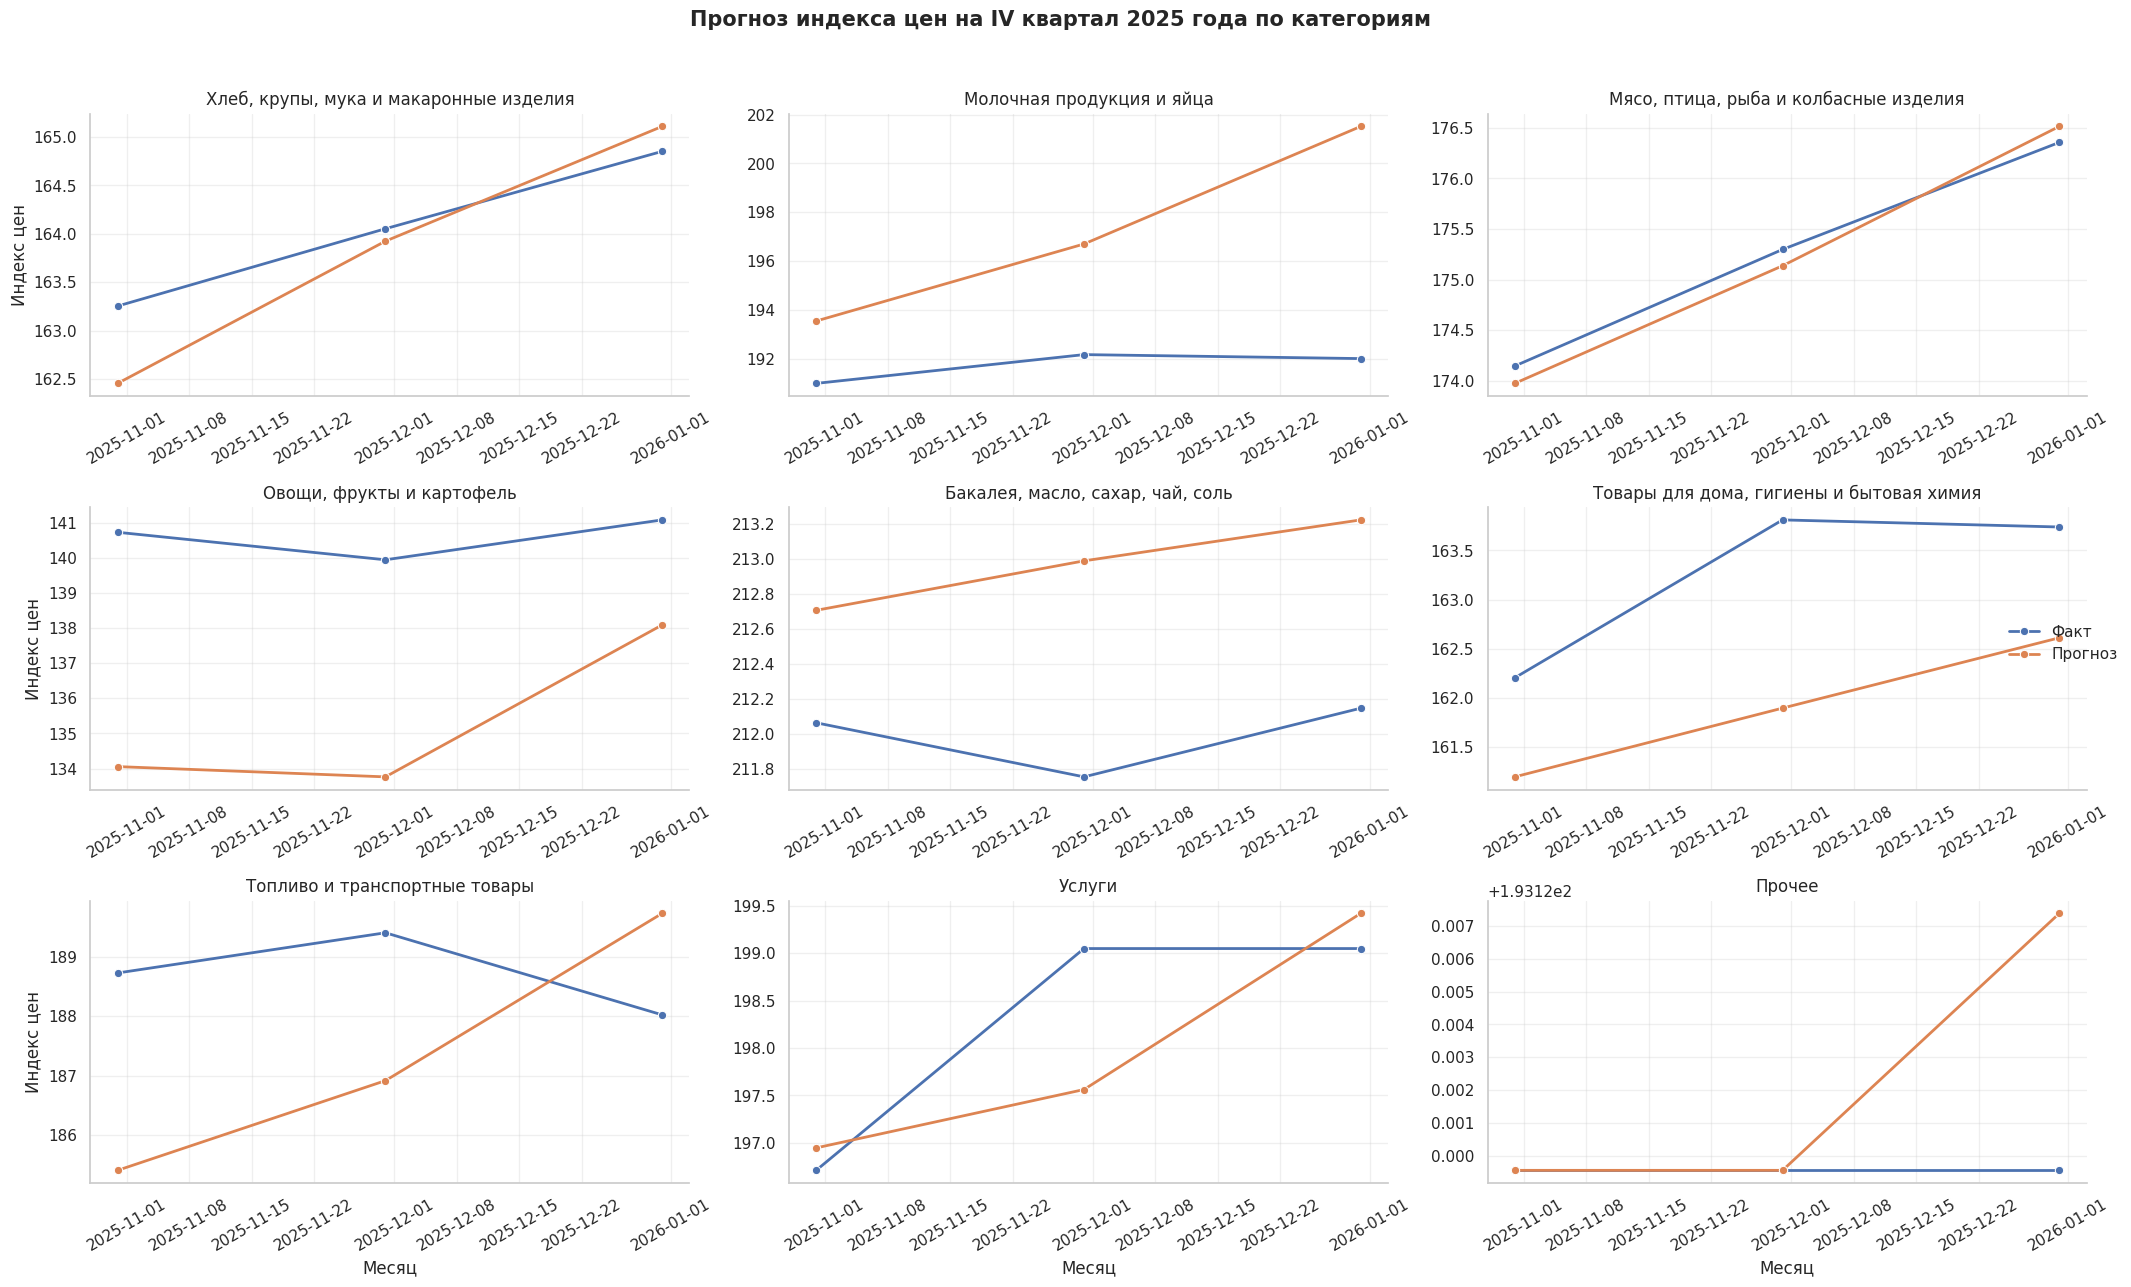

In [28]:
price_plot = pd.concat(
    [
        best_price_q4_predictions[
            ["month_end", "product_group_name", "y"]
        ].rename(columns={"y": "value"}).assign(series="Факт"),
        best_price_q4_predictions[
            ["month_end", "product_group_name", "yhat"]
        ].rename(columns={"yhat": "value"}).assign(series="Прогноз")
    ],
    ignore_index=True
)

g = sns.FacetGrid(
    price_plot,
    col="product_group_name",
    col_wrap=3,
    height=4.2,
    aspect=1.6,
    hue="series",
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.lineplot,
    x="month_end",
    y="value",
    marker="o",
    linewidth=2
)

g.add_legend(title="")
g.set_axis_labels("Месяц", "Индекс цен")
g.set_titles("{col_name}")

for ax in g.axes.flatten():
    ax.tick_params(axis="x", labelrotation=30)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    "Прогноз индекса цен на IV квартал 2025 года по категориям",
    y=1.02,
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

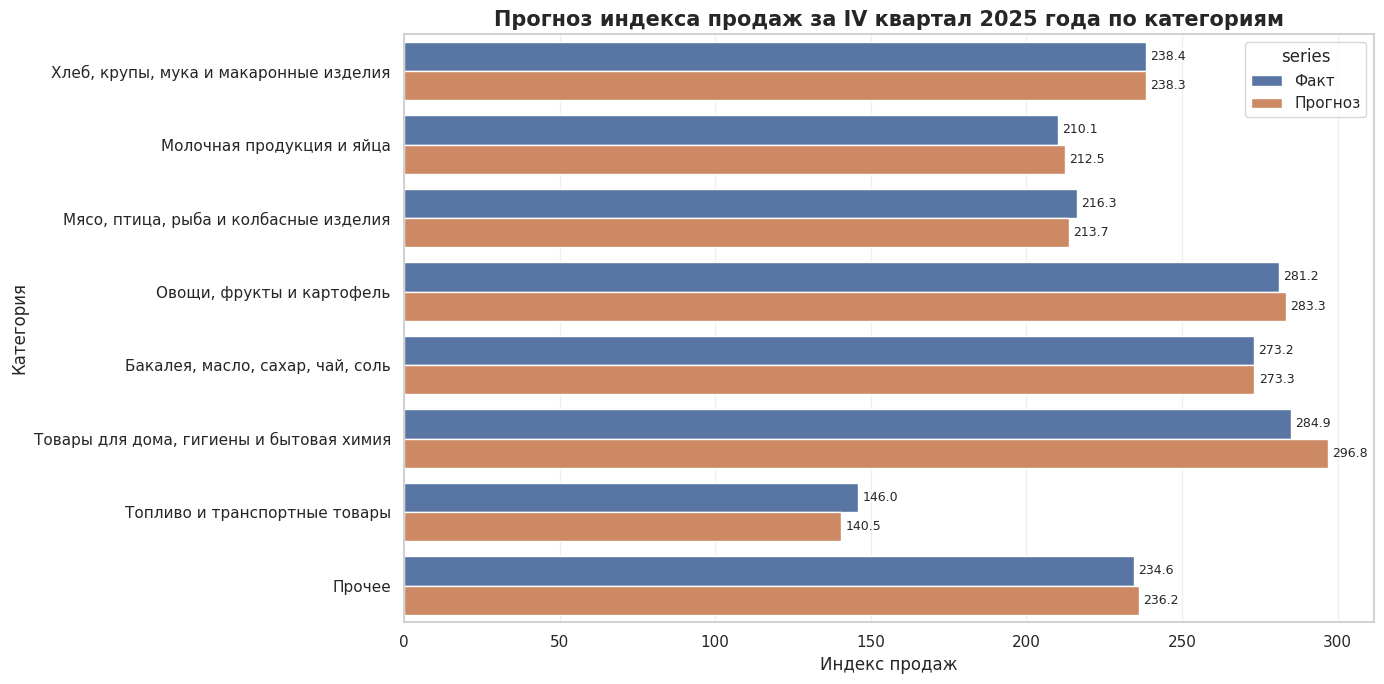

In [29]:
sales_plot = pd.concat(
    [
        best_sales_q4_predictions[
            ["product_group_name", "y"]
        ].rename(columns={"y": "value"}).assign(series="Факт"),
        best_sales_q4_predictions[
            ["product_group_name", "yhat"]
        ].rename(columns={"yhat": "value"}).assign(series="Прогноз")
    ],
    ignore_index=True
)

plt.figure(figsize=(14, 7))

ax = sns.barplot(
    data=sales_plot,
    x="value",
    y="product_group_name",
    hue="series"
)

plt.title(
    "Прогноз индекса продаж за IV квартал 2025 года по категориям",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Индекс продаж")
plt.ylabel("Категория")
plt.grid(axis="x", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3, fontsize=9)

plt.tight_layout()
plt.show()

In [30]:
price_q4_metrics_df.to_csv(
    RESULT_DIR / "price_q4_2025_all_metrics.csv",
    index=False,
    encoding="utf-8-sig"
)

price_q4_predictions_df.to_csv(
    RESULT_DIR / "price_q4_2025_all_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

best_price_q4_by_category.to_csv(
    RESULT_DIR / "price_q4_2025_best_by_category.csv",
    index=False,
    encoding="utf-8-sig"
)

best_price_q4_predictions.to_csv(
    RESULT_DIR / "price_q4_2025_best_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

sales_q4_metrics_df.to_csv(
    RESULT_DIR / "sales_q4_2025_all_metrics.csv",
    index=False,
    encoding="utf-8-sig"
)

sales_q4_predictions_df.to_csv(
    RESULT_DIR / "sales_q4_2025_all_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

best_sales_q4_by_category.to_csv(
    RESULT_DIR / "sales_q4_2025_best_by_category.csv",
    index=False,
    encoding="utf-8-sig"
)

best_sales_q4_predictions.to_csv(
    RESULT_DIR / "sales_q4_2025_best_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

price_model_summary.to_csv(
    RESULT_DIR / "price_q4_2025_model_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

sales_model_summary.to_csv(
    RESULT_DIR / "sales_q4_2025_model_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

final_summary.to_csv(
    RESULT_DIR / "q4_2025_final_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Файлы сохранены в:", RESULT_DIR)

Файлы сохранены в: /content/gdrive/MyDrive/rostat/final_q4_2025_forecast


In [38]:
display(
    best_sales_q4_by_category[
        ["product_group_name", "model_type", "MAE", "RMSE", "MAPE", "sMAPE"]
    ].round(3)
)

,product_group_name,model_type,MAE,RMSE,MAPE,sMAPE
0,"Хлеб, крупы, мука и макаронные изделия",SARIMAX,0.078,0.078,0.033,0.033
1,Молочная продукция и яйца,SARIMA,2.363,2.363,1.125,1.119
2,"Мясо, птица, рыба и колбасные изделия",SARIMA,2.547,2.547,1.177,1.184
3,"Овощи, фрукты и картофель",Seasonal Naive,2.091,2.091,0.744,0.741
4,"Бакалея, масло, сахар, чай, соль",SARIMA,0.121,0.121,0.044,0.044
5,"Товары для дома, гигиены и бытовая химия",Seasonal Naive,11.925,11.925,4.185,4.100
6,Топливо и транспортные товары,SARIMA,5.459,5.459,3.739,3.810
7,Прочее,SARIMAX,1.625,1.625,0.692,0.690


In [32]:
import pandas as pd

# Проверка цен
price_leak_check = price_q4_metrics_df.copy()

price_leak_check["train_end"] = pd.to_datetime(price_leak_check["train_end"])
price_leak_check["valid_start"] = pd.to_datetime(price_leak_check["valid_start"])
price_leak_check["valid_end"] = pd.to_datetime(price_leak_check["valid_end"])

price_leak_check["train_uses_q4_2025"] = (
    price_leak_check["train_end"] >= pd.Timestamp("2025-10-01")
)

price_leak_check["validation_is_q4_2025"] = (
    (price_leak_check["valid_start"] == pd.Timestamp("2025-10-31")) &
    (price_leak_check["valid_end"] == pd.Timestamp("2025-12-31"))
)

display(
    price_leak_check[
        [
            "target",
            "model",
            "product_group_code",
            "product_group_name",
            "train_start",
            "train_end",
            "valid_start",
            "valid_end",
            "train_uses_q4_2025",
            "validation_is_q4_2025"
        ]
    ].sort_values(["product_group_code", "model"])
)

print("Цены: есть ли обучение на IV квартале 2025?")
print(price_leak_check["train_uses_q4_2025"].any())

print("Цены: у всех validation именно IV квартал 2025?")
print(price_leak_check["validation_is_q4_2025"].all())

,target,model,product_group_code,product_group_name,train_start,train_end,valid_start,valid_end,train_uses_q4_2025,validation_is_q4_2025
1,price_index,"SARIMA (0,1,0)(0,1,0,12)",G01,"Хлеб, крупы, мука и макаронные изделия",2016-01-31,2025-09-30,2025-10-31,2025-12-31,False,True
4,price_index,"SARIMA (0,1,0)(0,1,1,12)",G01,"Хлеб, крупы, мука и макаронные изделия",2016-01-31,2025-09-30,2025-10-31,2025-12-31,False,True
2,price_index,"SARIMA (0,1,1)(0,1,0,12)",G01,"Хлеб, крупы, мука и макаронные изделия",2016-01-31,2025-09-30,2025-10-31,2025-12-31,False,True
5,price_index,"SARIMA (0,1,1)(0,1,1,12)",G01,"Хлеб, крупы, мука и макаронные изделия",2016-01-31,2025-09-30,2025-10-31,2025-12-31,False,True
3,price_index,"SARIMA (1,1,0)(0,1,0,12)",G01,"Хлеб, крупы, мука и макаронные изделия",2016-01-31,2025-09-30,2025-10-31,2025-12-31,False,True
...,...,...,...,...,...,...,...,...,...,...
58,price_index,"SARIMA (0,1,1)(0,1,0,12)",G99,Прочее,2016-01-31,2025-09-30,2025-10-31,2025-12-31,False,True
61,price_index,"SARIMA (0,1,1)(0,1,1,12)",G99,Прочее,2016-01-31,2025-09-30,2025-10-31,2025-12-31,False,True
59,price_index,"SARIMA (1,1,0)(0,1,0,12)",G99,Прочее,2016-01-31,2025-09-30,2025-10-31,2025-12-31,False,True
62,price_index,"SARIMA (1,1,0)(0,1,1,12)",G99,Прочее,2016-01-31,2025-09-30,2025-10-31,2025-12-31,False,True


Цены: есть ли обучение на IV квартале 2025?
False
Цены: у всех validation именно IV квартал 2025?
True


In [33]:
sales_leak_check = sales_q4_metrics_df.copy()

sales_leak_check["train_end"] = pd.to_datetime(sales_leak_check["train_end"])
sales_leak_check["valid_start"] = pd.to_datetime(sales_leak_check["valid_start"])
sales_leak_check["valid_end"] = pd.to_datetime(sales_leak_check["valid_end"])

sales_leak_check["train_uses_q4_2025"] = (
    sales_leak_check["train_end"] >= pd.Timestamp("2025-12-31")
)

sales_leak_check["validation_is_q4_2025"] = (
    (sales_leak_check["valid_start"] == pd.Timestamp("2025-12-31")) &
    (sales_leak_check["valid_end"] == pd.Timestamp("2025-12-31"))
)

display(
    sales_leak_check[
        [
            "target",
            "model",
            "product_group_code",
            "product_group_name",
            "train_start",
            "train_end",
            "valid_start",
            "valid_end",
            "train_uses_q4_2025",
            "validation_is_q4_2025"
        ]
    ].sort_values(["product_group_code", "model"])
)

print("Продажи: есть ли обучение на IV квартале 2025?")
print(sales_leak_check["train_uses_q4_2025"].any())

print("Продажи: у всех validation именно IV квартал 2025?")
print(sales_leak_check["validation_is_q4_2025"].all())

,target,model,product_group_code,product_group_name,train_start,train_end,valid_start,valid_end,train_uses_q4_2025,validation_is_q4_2025
1,sales_index,"SARIMA (0,1,0)(0,1,0,4)",G01,"Хлеб, крупы, мука и макаронные изделия",2017-03-31,2025-09-30,2025-12-31,2025-12-31,False,True
2,sales_index,"SARIMA (0,1,0)(0,1,1,4)",G01,"Хлеб, крупы, мука и макаронные изделия",2017-03-31,2025-09-30,2025-12-31,2025-12-31,False,True
3,sales_index,"SARIMA (1,1,0)(0,1,0,4)",G01,"Хлеб, крупы, мука и макаронные изделия",2017-03-31,2025-09-30,2025-12-31,2025-12-31,False,True
4,sales_index,"SARIMA (1,1,0)(0,1,1,4)",G01,"Хлеб, крупы, мука и макаронные изделия",2017-03-31,2025-09-30,2025-12-31,2025-12-31,False,True
5,sales_index,"SARIMAX (0,1,0)(0,1,0,4) + price_index_lag1",G01,"Хлеб, крупы, мука и макаронные изделия",2017-06-30,2025-09-30,2025-12-31,2025-12-31,False,True
...,...,...,...,...,...,...,...,...,...,...
68,sales_index,"SARIMAX (0,1,0)(0,1,0,4) + price_index_lag1",G99,Прочее,2017-06-30,2025-09-30,2025-12-31,2025-12-31,False,True
69,sales_index,"SARIMAX (0,1,0)(0,1,0,4) + price_index_lag4",G99,Прочее,2018-03-31,2025-09-30,2025-12-31,2025-12-31,False,True
70,sales_index,"SARIMAX (1,1,0)(0,1,0,4) + price_index_lag1",G99,Прочее,2017-06-30,2025-09-30,2025-12-31,2025-12-31,False,True
71,sales_index,"SARIMAX (1,1,0)(0,1,0,4) + price_index_lag4",G99,Прочее,2018-03-31,2025-09-30,2025-12-31,2025-12-31,False,True


Продажи: есть ли обучение на IV квартале 2025?
False
Продажи: у всех validation именно IV квартал 2025?
True


In [34]:
price_split_check = []

for group_code, category_df in monthly_data.groupby("product_group_code"):
    category_df = category_df.sort_values("month_end").copy()
    
    train_df = category_df[category_df["month_end"] <= pd.Timestamp("2025-09-30")].copy()
    valid_df = category_df[
        (category_df["month_end"] >= pd.Timestamp("2025-10-31")) &
        (category_df["month_end"] <= pd.Timestamp("2025-12-31"))
    ].copy()
    
    price_split_check.append({
        "product_group_code": group_code,
        "product_group_name": category_df["product_group_name"].iloc[0],
        "train_start": train_df["month_end"].min(),
        "train_end": train_df["month_end"].max(),
        "valid_start": valid_df["month_end"].min(),
        "valid_end": valid_df["month_end"].max(),
        "train_months": len(train_df),
        "valid_months": len(valid_df),
        "train_has_q4_2025": (train_df["month_end"] >= pd.Timestamp("2025-10-01")).any(),
        "valid_only_q4_2025": set(valid_df["month"].unique()) == {10, 11, 12}
    })

price_split_check_df = pd.DataFrame(price_split_check)

display(price_split_check_df)

print("Цены: есть категории, где train содержит IV квартал 2025?")
print(price_split_check_df["train_has_q4_2025"].any())

print("Цены: у всех validation только октябрь-декабрь 2025?")
print(price_split_check_df["valid_only_q4_2025"].all())

,product_group_code,product_group_name,train_start,train_end,valid_start,valid_end,train_months,valid_months,train_has_q4_2025,valid_only_q4_2025
0,G01,"Хлеб, крупы, мука и макаронные изделия",2016-01-31,2025-09-30,2025-10-31,2025-12-31,117,3,False,True
1,G02,Молочная продукция и яйца,2016-01-31,2025-09-30,2025-10-31,2025-12-31,117,3,False,True
2,G03,"Мясо, птица, рыба и колбасные изделия",2016-01-31,2025-09-30,2025-10-31,2025-12-31,117,3,False,True
3,G04,"Овощи, фрукты и картофель",2016-01-31,2025-09-30,2025-10-31,2025-12-31,117,3,False,True
4,G05,"Бакалея, масло, сахар, чай, соль",2016-01-31,2025-09-30,2025-10-31,2025-12-31,117,3,False,True
5,G07,"Товары для дома, гигиены и бытовая химия",2016-01-31,2025-09-30,2025-10-31,2025-12-31,117,3,False,True
6,G10,Топливо и транспортные товары,2016-01-31,2025-09-30,2025-10-31,2025-12-31,117,3,False,True
7,G11,Услуги,2016-01-31,2025-09-30,2025-10-31,2025-12-31,117,3,False,True
8,G99,Прочее,2016-01-31,2025-09-30,2025-10-31,2025-12-31,117,3,False,True


Цены: есть категории, где train содержит IV квартал 2025?
False
Цены: у всех validation только октябрь-декабрь 2025?
True


In [35]:
sales_split_check = []

for group_code, category_df in arimax_data.groupby("product_group_code"):
    category_df = category_df.sort_values("period_end").copy()
    
    train_df = category_df[category_df["period_end"] <= pd.Timestamp("2025-09-30")].copy()
    valid_df = category_df[category_df["period_end"] == pd.Timestamp("2025-12-31")].copy()
    
    sales_split_check.append({
        "product_group_code": group_code,
        "product_group_name": category_df["product_group_name"].iloc[0],
        "train_start": train_df["period_end"].min(),
        "train_end": train_df["period_end"].max(),
        "valid_start": valid_df["period_end"].min(),
        "valid_end": valid_df["period_end"].max(),
        "train_quarters": len(train_df),
        "valid_quarters": len(valid_df),
        "train_has_q4_2025": (train_df["period_end"] >= pd.Timestamp("2025-12-31")).any(),
        "valid_only_q4_2025": set(valid_df["quarter"].unique()) == {4}
    })

sales_split_check_df = pd.DataFrame(sales_split_check)

display(sales_split_check_df)

print("Продажи: есть категории, где train содержит IV квартал 2025?")
print(sales_split_check_df["train_has_q4_2025"].any())

print("Продажи: у всех validation только IV квартал 2025?")
print(sales_split_check_df["valid_only_q4_2025"].all())

,product_group_code,product_group_name,train_start,train_end,valid_start,valid_end,train_quarters,valid_quarters,train_has_q4_2025,valid_only_q4_2025
0,G01,"Хлеб, крупы, мука и макаронные изделия",2017-03-31,2025-09-30,2025-12-31,2025-12-31,35,1,False,True
1,G02,Молочная продукция и яйца,2017-03-31,2025-09-30,2025-12-31,2025-12-31,35,1,False,True
2,G03,"Мясо, птица, рыба и колбасные изделия",2017-03-31,2025-09-30,2025-12-31,2025-12-31,35,1,False,True
3,G04,"Овощи, фрукты и картофель",2017-03-31,2025-09-30,2025-12-31,2025-12-31,35,1,False,True
4,G05,"Бакалея, масло, сахар, чай, соль",2017-03-31,2025-09-30,2025-12-31,2025-12-31,35,1,False,True
5,G07,"Товары для дома, гигиены и бытовая химия",2017-03-31,2025-09-30,2025-12-31,2025-12-31,35,1,False,True
6,G10,Топливо и транспортные товары,2017-03-31,2025-09-30,2025-12-31,2025-12-31,35,1,False,True
7,G99,Прочее,2017-03-31,2025-09-30,2025-12-31,2025-12-31,35,1,False,True


Продажи: есть категории, где train содержит IV квартал 2025?
False
Продажи: у всех validation только IV квартал 2025?
True


In [36]:
display(
    best_price_q4_by_category[
        ["product_group_name", "model", "MAE", "RMSE", "MAPE", "sMAPE"]
    ].round(3)
)

,product_group_name,model,MAE,RMSE,MAPE,sMAPE
0,"Хлеб, крупы, мука и макаронные изделия","SARIMA (0,1,0)(0,1,0,12)",0.395,0.490,0.241,0.242
1,Молочная продукция и яйца,"SARIMA (1,1,0)(0,1,1,12)",5.529,6.255,2.881,2.829
2,"Мясо, птица, рыба и колбасные изделия","SARIMA (0,1,0)(0,1,0,12)",0.163,0.164,0.093,0.093
3,"Овощи, фрукты и картофель","SARIMA (0,1,0)(0,1,1,12)",5.279,5.525,3.758,3.837
4,"Бакалея, масло, сахар, чай, соль","SARIMA (0,1,0)(0,1,1,12)",0.984,1.016,0.464,0.463
5,"Товары для дома, гигиены и бытовая химия","SARIMA (0,1,1)(0,1,1,12)",1.351,1.410,0.827,0.831
6,Топливо и транспортные товары,"SARIMA (0,1,1)(0,1,0,12)",2.502,2.588,1.326,1.332
7,Услуги,"SARIMA (1,1,0)(0,1,0,12)",0.698,0.895,0.351,0.352
8,Прочее,"SARIMA (0,1,0)(0,1,0,12)",0.003,0.005,0.001,0.001


In [39]:
display(
    best_sales_q4_by_category[
        ["product_group_name", "model_type", "MAE", "RMSE", "MAPE", "sMAPE"]
    ].round(3)
)

,product_group_name,model_type,MAE,RMSE,MAPE,sMAPE
0,"Хлеб, крупы, мука и макаронные изделия",SARIMAX,0.078,0.078,0.033,0.033
1,Молочная продукция и яйца,SARIMA,2.363,2.363,1.125,1.119
2,"Мясо, птица, рыба и колбасные изделия",SARIMA,2.547,2.547,1.177,1.184
3,"Овощи, фрукты и картофель",Seasonal Naive,2.091,2.091,0.744,0.741
4,"Бакалея, масло, сахар, чай, соль",SARIMA,0.121,0.121,0.044,0.044
5,"Товары для дома, гигиены и бытовая химия",Seasonal Naive,11.925,11.925,4.185,4.100
6,Топливо и транспортные товары,SARIMA,5.459,5.459,3.739,3.810
7,Прочее,SARIMAX,1.625,1.625,0.692,0.690
